In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np

In [2]:
envs = ["atari_battle_zone", "atari_double_dunk", "atari_phoenix", "atari_this_game", "atari_battle_zone", "box2d_lunar_lander", "box2d_continuous_lunar_lander", "box2d_bipedal_walker", "cc_acrobot", "cc_cartpole", "cc_mountain_car", "cc_continuous_mountain_car", "cc_pendulum", "minigrid_door_key", "minigrid_empty_random", "minigrid_four_rooms", "minigrid_unlock", "brax_ant", "brax_halfcheetah", "brax_hopper", "brax_humanoid"]
algos = ["ppo", "dqn", "sac"]

data = []
for env in envs:
    for algo in algos:
        try:
            partial_data = pd.read_csv(f"arlbench_data/256_10/{env}_{algo}.csv")
            partial_data["env_name"] = env
            partial_data["algorithm"] = algo
            data.append(partial_data)
        except FileNotFoundError:
            continue
data = pd.concat(data)

In [14]:
## add domain
data["domain"] = data["env_name"].apply(lambda x: x.split("_")[0])

In [3]:
# normalization cross-algorithm per environment
data["normed_performance"] = data.groupby("env_name")["performance"].transform(
    lambda x: (x - x.min()) / (x.max() - x.min() + 1e-8)
)

# on data_two we normalize per env and algorithm
data["normed_performance_per_alg"] = data.groupby(["env_name", "algorithm"])["performance"].transform(
    lambda x: (x - x.min()) / (x.max() - x.min() + 1e-8)
)

# on data_two we normalize per env and algorithm
data["_seed_avg"] = data.groupby(["env_name", "algorithm", "config_id"])["performance"].transform("mean")
data["normed_performance_per_alg_seedavg"] = data.groupby(["env_name", "algorithm"], group_keys=False).apply(
    lambda g: (g["performance"] - g["_seed_avg"].min()) / (g["_seed_avg"].max() - g["_seed_avg"].min() + 1e-8)
)
data.drop(columns=["_seed_avg"], inplace=True)

/var/folders/5n/lj6nx7xj3mx2yb3sk947mnlc0000gn/T/ipykernel_551/355322313.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data["normed_performance_per_alg_seedavg"] = data.groupby(["env_name", "algorithm"], group_keys=False).apply(


In [4]:
for env in data["env_name"].unique():
    
    for algo in data["algorithm"].unique():
        subset = data[(data["env_name"] == env) & (data["algorithm"] == algo)]
        pass

In [5]:
def compute_rankings_counting(mu: np.ndarray, sigma: np.ndarray) -> np.ndarray:
    """
    Compute rankings based on counting overlaps, without sorting or binary search.
    
    For each configuration j, we count:
    - How many configurations have upper bound (μ + σ) below j's lower bound (μ - σ)
      → these are strictly worse (gives lower bound on rank)
    - How many configurations have lower bound (μ - σ) below j's upper bound (μ + σ)
      → these overlap or are worse (gives upper bound on rank)
    
    The rank is the average of these bounds.
    
    Args:
        mu: Array of shape (n,) with aggregate metrics for each configuration
        sigma: Array of shape (n,) with spread metrics for each configuration
    
    Returns:
        ranks: Array of shape (n,) with the computed rank for each configuration
    """
    n = len(mu)
    
    # Compute bounds for all configurations
    upper_bounds = mu + sigma  # Best case for each config
    lower_bounds = mu - sigma  # Worst case for each config
    
    # For each configuration j, compute rank bounds
    l = np.zeros(n)  # Lower rank bound (1-indexed rank)
    u = np.zeros(n)  # Upper rank bound (1-indexed rank)
    
    for j in range(n):
        # Count how many configurations are strictly better than j
        # (their lower bound is above j's upper bound)
        strictly_better = np.sum(lower_bounds > upper_bounds[j])
        
        # Count how many configurations could potentially be better or equal
        # (their upper bound is at or above j's lower bound)
        potentially_better_or_equal = np.sum(upper_bounds >= lower_bounds[j])
        
        # l[j] = number of configs strictly better + 1 (best possible rank for j)
        l[j] = strictly_better + 1
        
        # u[j] = number of configs that could be better or equal (worst possible rank for j)
        u[j] = potentially_better_or_equal
    
    # Average rank
    ranks = (l + u) / 2
    
    return ranks

In [6]:
perf_column = "normed_performance_per_alg"

In [7]:
rank_dict = {}  
envs = data["env_name"].unique()
algos = data["algorithm"].unique()

for algo in algos:
    rank_dict[algo] = {}
    for env in envs:

        subset = data[(data["env_name"] == env) & (data["algorithm"] == algo)]

        # 1. Identify columns starting with 'hp_config.' that have no NaN entries
        hp_config_cols = [col for col in subset.columns 
                        if col.startswith('hp_config.') and subset[col].notna().all()]

        H = [col.replace("hp_config.", "") for col in hp_config_cols]
        

        for i, H_i in enumerate(H):

            H_i_results = {}

            for j, h_j in enumerate(subset[f"hp_config.{H_i}"].unique().tolist()):
                subsub = subset[subset[f"hp_config.{H_i}"] == h_j]

                # print(f"Processing {algo} - {env} - {H_i}={h_j} with {len(subsub)} entries")
                
                
                H_i_results.update({h_j: {
                    "mu": subsub[perf_column].mean(),
                    "sigma": subsub[perf_column].std()
                }})
            
            vals, mu, sigma = [], [], []
            for v, stats in H_i_results.items():
                vals.append(v)
                mu.append(stats["mu"])
                sigma.append(stats["sigma"])

            vals = np.array(vals)
            mu = np.array(mu)
            sigma = np.array(sigma)

            ranks_i = compute_rankings_counting(mu, sigma)

            if H_i not in rank_dict[algo]:
                rank_dict[algo][H_i] = {env: ranks_i}
            else:
                rank_dict[algo][H_i].update({env: ranks_i})


In [8]:
# rank_dict

In [9]:
THCs = {}

for algo in algos:
    for H_i, env_ranks in rank_dict[algo].items():
        
        filtered = {env: ranks for env, ranks in env_ranks.items() 
                    if ranks.shape[0] > 0}
        
        if not filtered:
            # print(f"[{algo}] {H_i}: No valid environments")
            continue
        
        # Find minimum length across all arrays
        min_len = min(ranks.shape[0] for ranks in filtered.values())
        
        # Truncate all arrays to the same length
        ranks_matrix = np.array([ranks[:min_len] for ranks in filtered.values()])
        
        # print(f"[{algo}] {H_i}: {ranks_matrix.shape}")
        ptps = np.max(ranks_matrix, axis=0) - np.min(ranks_matrix, axis=0)

        # print(f"[{algo}] {H_i}: ptps={ptps}, len(ptps)={len(ptps)}")

        # THCs[(algo, H_i)] = ptps / (len(ptps) * (len(ptps) - 1))
        THCs[(algo, H_i)] = ptps / (len(ptps))

In [10]:
# THCs

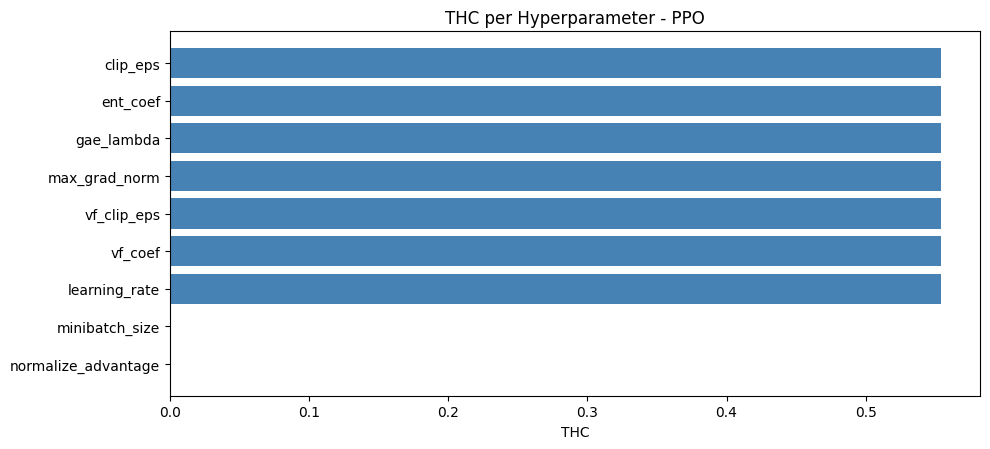

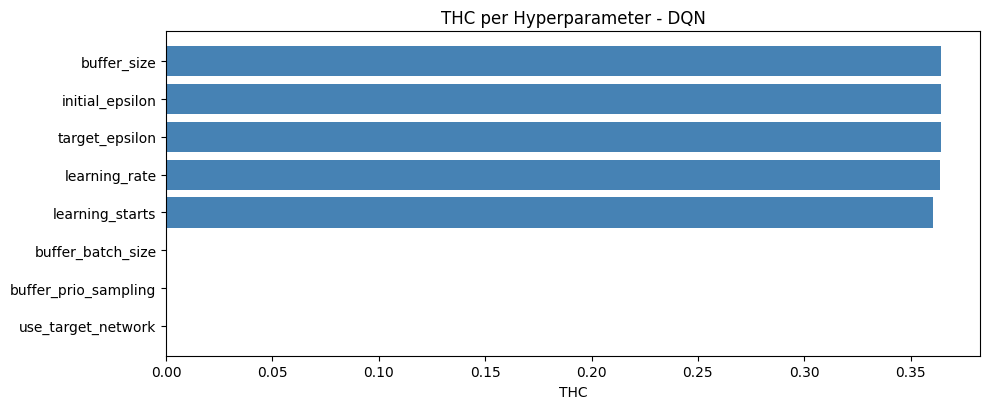

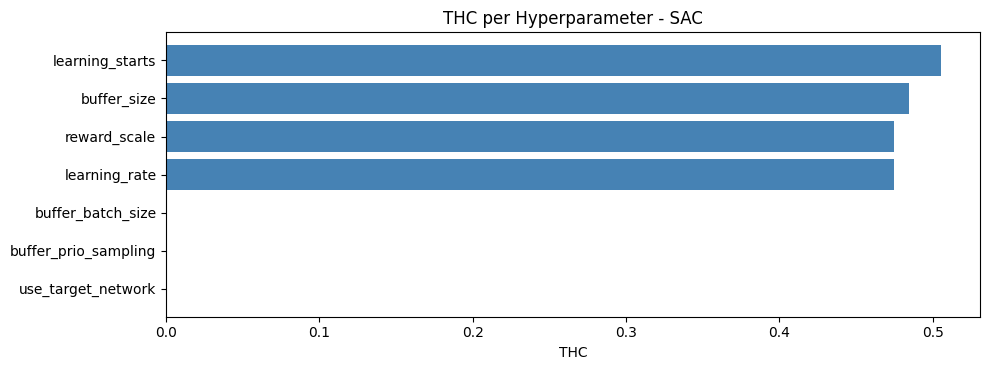

In [11]:
for algo in algos:
    # Filter THCs for this algorithm
    algo_thcs = {H_i: thc for (a, H_i), thc in THCs.items() if a == algo}
    
    if not algo_thcs:
        continue
    
    # Sort by THC value (mean if array)
    sorted_items = sorted(algo_thcs.items(), 
                          key=lambda x: np.mean(x[1]), reverse=True)
    
    hp_names = [item[0] for item in sorted_items]
    thc_values = [np.mean(item[1]) for item in sorted_items]
    
    # Create horizontal bar plot
    fig, ax = plt.subplots(figsize=(10, len(hp_names) * 0.4 + 1))
    
    y_pos = np.arange(len(hp_names))
    ax.barh(y_pos, thc_values, color='steelblue')
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(hp_names)
    ax.invert_yaxis()  # Highest value at top
    ax.set_xlabel('THC')
    ax.set_title(f'THC per Hyperparameter - {algo.upper()}')
    
    plt.tight_layout()
    plt.show()

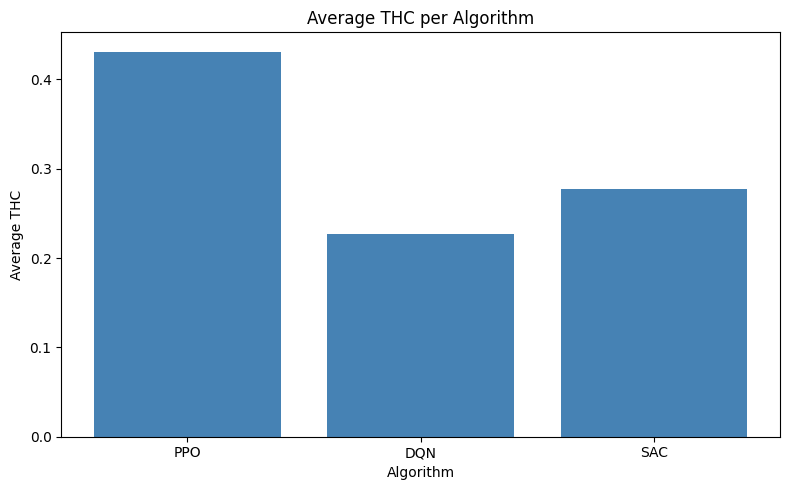

In [12]:
# Compute average THC per algorithm
avg_thcs = {}
for algo in algos:
    algo_thcs = [np.mean(thc) for (a, H_i), thc in THCs.items() if a == algo]
    if algo_thcs:
        avg_thcs[algo] = np.mean(algo_thcs)

# Create bar plot
fig, ax = plt.subplots(figsize=(8, 5))

algo_names = list(avg_thcs.keys())
thc_values = list(avg_thcs.values())

x_pos = np.arange(len(algo_names))
ax.bar(x_pos, thc_values, color='steelblue')

ax.set_xticks(x_pos)
ax.set_xticklabels([a.upper() for a in algo_names])
ax.set_ylabel('Average THC')
ax.set_xlabel('Algorithm')
ax.set_title('Average THC per Algorithm')

plt.tight_layout()
plt.show()

#### Remark: Because we work with ranks, this is invariant under normalization